In [49]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
import subprocess
import json

# compile binary so subsequent ones are fast
subprocess.run(["cargo", "build", "--profile", "fast", "--bin", "bench"], cwd="../../wasm", check=True)

def run_bench(n: int, runs: int = 200, timeout: float = 30) -> dict:
    cmd = ["cargo", "run", "--profile", "fast", "--bin", "bench", "--", str(n), str(runs)]
    result = subprocess.run(cmd, capture_output=True, text=True, cwd="../../wasm", timeout=timeout)
    result.check_returncode()
    return json.loads(result.stdout)


In [67]:
import time

ns_to_plot = list(range(6, 21))
all_data = {}

for n in ns_to_plot:
    t1 = time.time()
    all_data[n] = run_bench(n, runs=200)
    print(f"n={n} done ({time.time()-t1:.1f}s)")

n=6 done (6.3s)
n=7 done (0.2s)
n=8 done (0.2s)
n=9 done (0.2s)
n=10 done (0.2s)
n=11 done (0.3s)
n=12 done (0.4s)
n=13 done (0.5s)
n=14 done (0.7s)
n=15 done (1.1s)
n=16 done (1.6s)
n=17 done (2.9s)
n=18 done (4.3s)
n=19 done (7.0s)
n=20 done (12.9s)


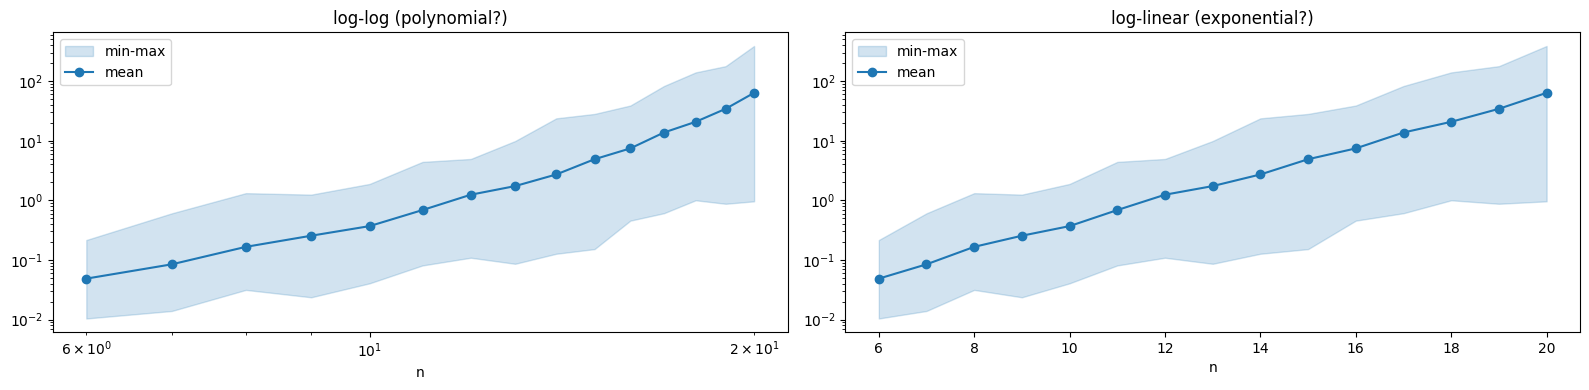

R² log-log  (polynomial):   0.9751  →  O(n^5.89)
R² log-lin  (exponential):  0.9988  →  ~1.650x per +1 n
verdict: exponential


In [78]:
from scipy import stats

ns = np.array(ns_to_plot, dtype=float)
means = np.array([np.mean(all_data[n]["ms"]) for n in ns_to_plot])
lows = np.array([np.min(all_data[n]["ms"]) for n in ns_to_plot])
highs = np.array([np.max(all_data[n]["ms"]) for n in ns_to_plot])

# plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))

# log-log (straight = polynomial)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.fill_between(ns, lows, highs, alpha=0.2, color="tab:blue", label="min-max")
ax1.plot(ns, means, marker="o", color="tab:blue", label="mean")
ax1.set_xlabel("n")
ax1.set_title("log-log (polynomial?)")
ax1.legend()

# log-linear (straight = exponential)
ax2.set_yscale("log")
ax2.fill_between(ns, lows, highs, alpha=0.2, color="tab:blue", label="min-max")
ax2.plot(ns, means, marker="o", color="tab:blue", label="mean")
ax2.set_xlabel("n")
ax2.set_title("log-linear (exponential?)")
ax2.legend()

plt.tight_layout()
plt.show()

# big-O
log_ns, log_means = np.log(ns), np.log(means)

r2_poly = stats.pearsonr(log_ns, log_means).statistic ** 2
r2_exp = stats.pearsonr(ns, log_means).statistic ** 2

poly_slope, _ = np.polyfit(log_ns, log_means, 1)
exp_slope, _ = np.polyfit(ns, log_means, 1)

verdict = "exponential" if r2_exp > r2_poly else "polynomial"
print(f"R² log-log  (polynomial):   {r2_poly:.4f}  →  O(n^{poly_slope:.2f})")
print(
    f"R² log-lin  (exponential):  {r2_exp:.4f}  →  ~{np.exp(exp_slope):.3f}x per +1 n"
)
print(f"verdict: {verdict}")

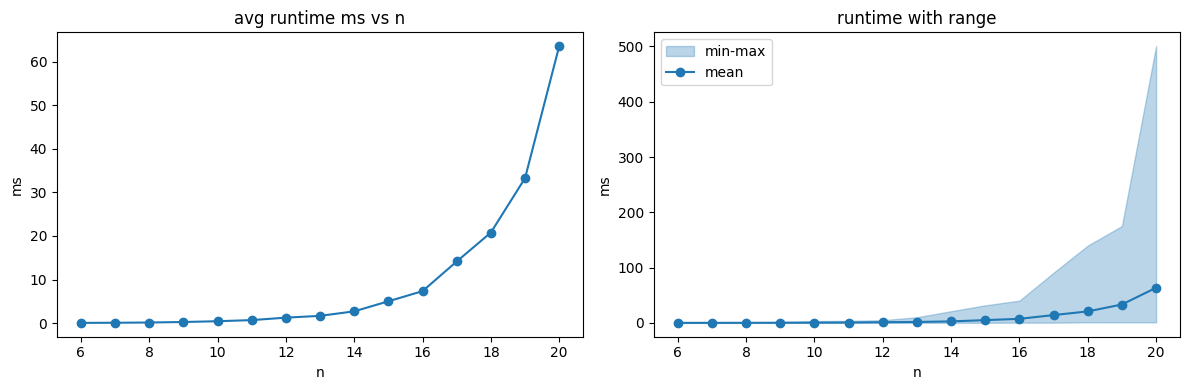

In [53]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

means = np.array([np.mean(all_data[n]["ms"]) for n in ns_to_plot])
lows  = np.array([np.min(all_data[n]["ms"])  for n in ns_to_plot])
highs = np.array([np.max(all_data[n]["ms"])  for n in ns_to_plot])

ax1.plot(ns_to_plot, means, marker="o")
ax1.set_xlabel("n"); ax1.set_ylabel("ms"); ax1.set_title("avg runtime ms vs n")

ax2.fill_between(ns_to_plot, lows, highs, alpha=0.3, color="tab:blue", label="min-max")
ax2.plot(ns_to_plot, means, marker="o", color="tab:blue", label="mean")
ax2.set_xlabel("n"); ax2.set_ylabel("ms"); ax2.set_title("runtime with range")
ax2.legend()

plt.tight_layout()
plt.show()

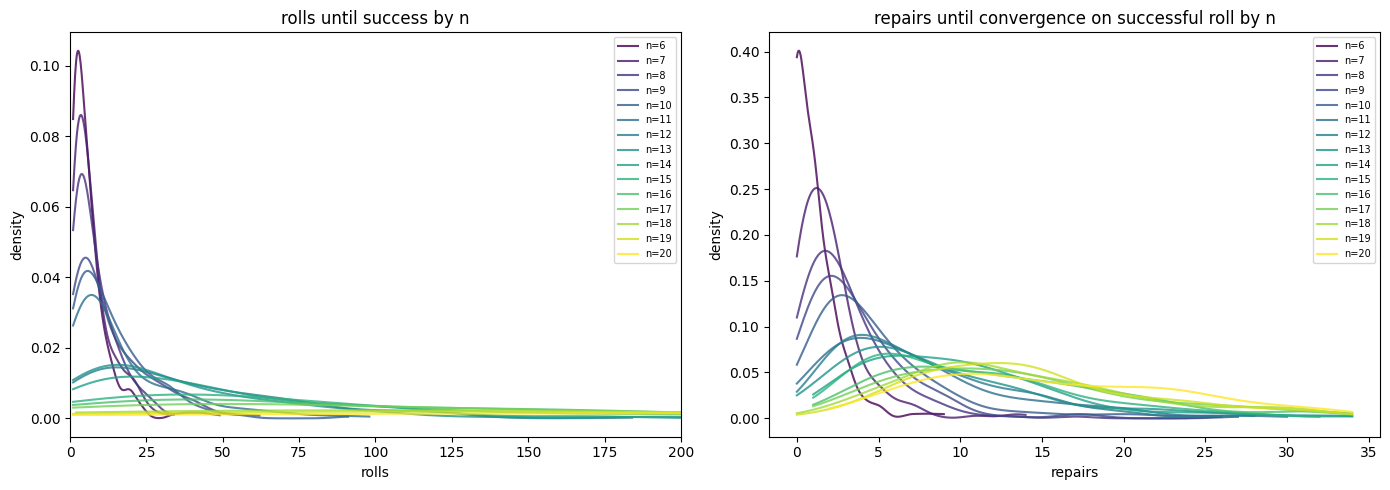

In [54]:
from scipy.stats import gaussian_kde

palette = plt.cm.viridis(np.linspace(0, 1, len(ns_to_plot)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for color, n in zip(palette, ns_to_plot):
    for ax, key in [(ax1, "rolls"), (ax2, "success_repairs")]:
        vals = np.array(all_data[n][key], dtype=float)
        if vals.std() == 0:
            continue
        kde = gaussian_kde(vals)
        xs = np.linspace(vals.min(), vals.max(), 200)
        ax.plot(xs, kde(xs), color=color, alpha=0.8, label=f"n={n}")

ax1.set_xlabel("rolls"); ax1.set_ylabel("density")
ax1.set_xlim(left=0, right=200)
ax1.set_title("rolls until success by n")
ax1.legend(fontsize=7)

ax2.set_xlabel("repairs"); ax2.set_ylabel("density")
ax2.set_title("repairs until convergence on successful roll by n")
ax2.legend(fontsize=7)

plt.tight_layout()
plt.show()

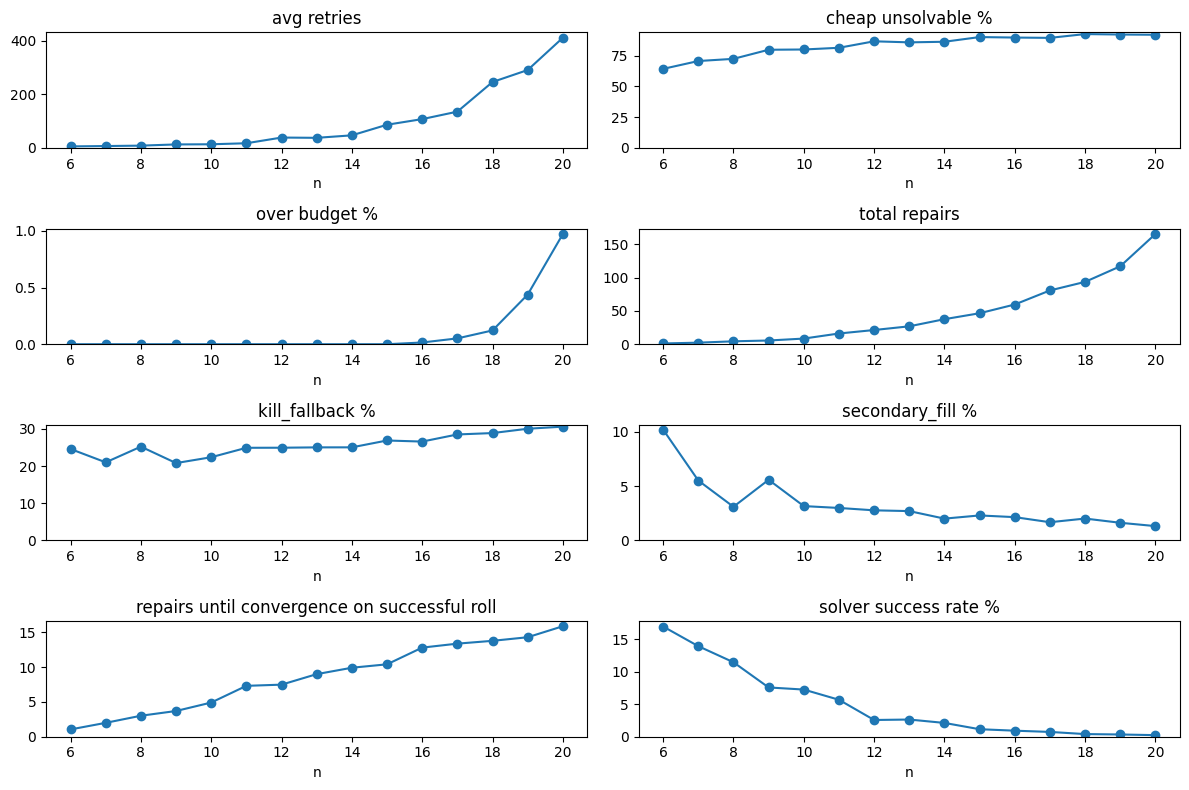

In [77]:
def avg(n, key):
    return np.mean(all_data[n][key])


def pct(n, key, denom_key):
    return 100.0 * np.sum(all_data[n][key]) / np.sum(all_data[n][denom_key])


keys_fns = [
    ("avg retries", lambda n: avg(n, "rolls")),
    ("cheap unsolvable %", lambda n: pct(n, "unsolvable", "rolls")),
    ("over budget %", lambda n: pct(n, "over_budget", "solves")),
    ("total repairs", lambda n: avg(n, "repairs")),
    ("kill_fallback %", lambda n: pct(n, "kill_fallback", "repairs")),
    ("secondary_fill %", lambda n: pct(n, "secondary_fills", "rolls")),
    ("repairs until convergence on successful roll", lambda n: avg(n, "success_repairs")),
    ("solver success rate %", lambda n: 100 / avg(n, "rolls")), # hacky geom dist approx
]

fig, axes = plt.subplots(4, 2, figsize=(12, 8))
for ax, (title, fn) in zip(axes.flat, keys_fns):
    ax.plot(ns_to_plot, [fn(n) for n in ns_to_plot], marker="o")
    ax.set_xlabel("n")
    ax.set_title(title)
    ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

fit: 0.44 * e^(0.3799 * n)


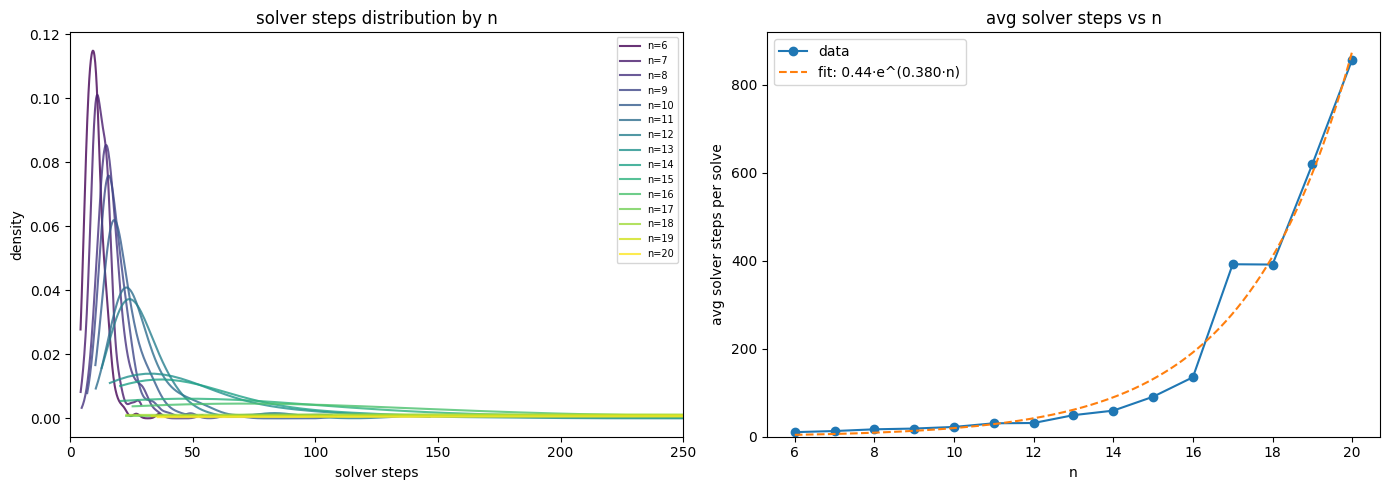

In [75]:
from scipy.stats import gaussian_kde
from scipy.optimize import curve_fit

palette = plt.cm.viridis(np.linspace(0, 1, len(ns_to_plot)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for color, n in zip(palette, ns_to_plot):
    steps = np.array(all_data[n]["solver_steps"], dtype=float)
    solves = np.array(all_data[n]["solves"], dtype=float)
    vals = steps / solves
    if vals.std() == 0:
        continue
    kde = gaussian_kde(vals)
    xs = np.linspace(vals.min(), vals.max(), 200)
    ax1.plot(xs, kde(xs), color=color, alpha=0.8, label=f"n={n}")

ax1.set_xlabel("solver steps")
ax1.set_ylabel("density")
ax1.set_title("solver steps distribution by n")
ax1.set_xlim(left=0, right=250)
ax1.legend(fontsize=7)

avg_steps = [np.mean(np.array(all_data[n]["solver_steps"]) / np.array(all_data[n]["solves"])) for n in ns_to_plot]

def exp_model(x, a, b):
    return a * np.exp(b * x)

popt, _ = curve_fit(exp_model, ns_to_plot, avg_steps, p0=[1, 0.1])
a, b = popt

ns_smooth = np.linspace(min(ns_to_plot), max(ns_to_plot), 200)
ax2.plot(ns_to_plot, avg_steps, marker="o", color="tab:blue", label="data")
ax2.plot(ns_smooth, exp_model(ns_smooth, a, b), "--", color="tab:orange", label=f"fit: {a:.2f}·e^({b:.3f}·n)")
ax2.set_xlabel("n")
ax2.set_ylabel("avg solver steps per solve")
ax2.set_title("avg solver steps vs n")
ax2.set_ylim(bottom=0)
ax2.legend()

print(f"fit: {a:.2f} * e^({b:.4f} * n)")

plt.tight_layout()
plt.show()

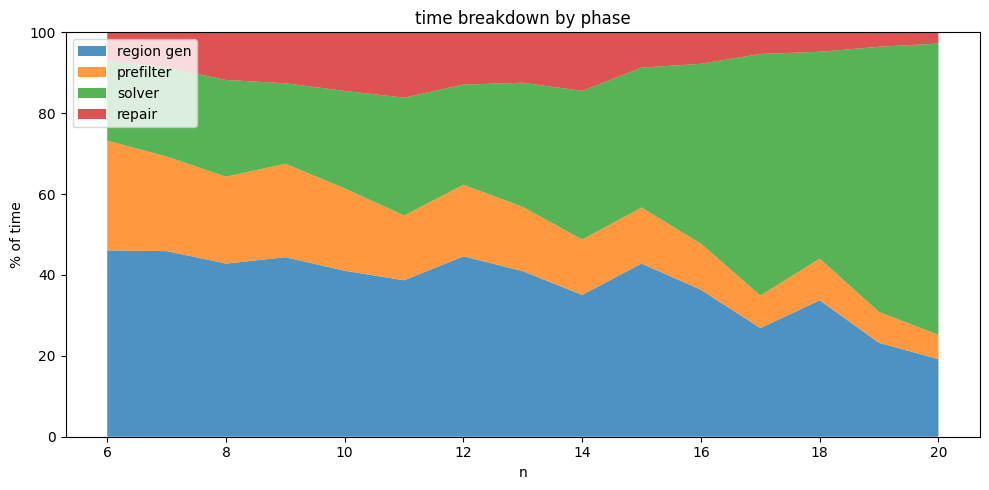

In [62]:
phases = ["t_regions", "t_solvable", "t_solve", "t_kill"]
labels = ["region gen", "prefilter", "solver", "repair"]
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

# compute each phase as % of total t_* time per n
pcts = []
for phase in phases:
    vals = []
    for n in ns_to_plot:
        total = sum(np.mean(all_data[n][p]) for p in phases)
        vals.append(100.0 * np.mean(all_data[n][phase]) / total)
    pcts.append(vals)

fig, ax = plt.subplots(figsize=(10, 5))
ax.stackplot(ns_to_plot, pcts, labels=labels, colors=colors, alpha=0.8)
ax.set_xlabel("n")
ax.set_ylabel("% of time")
ax.set_title("time breakdown by phase")
ax.set_ylim(0, 100)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


In [83]:
with open("baseline.json") as f:
    baseline_data = json.load(f)

print(f"{'n':>4}  {'cur_avg':>11}  {'cur_min':>11}  {'cur_max':>11}  |  {'base_avg':>11}  {'base_min':>11}  {'base_max':>11}")
print("-" * 86)
for n in ns_to_plot:
    b = np.array(baseline_data[str(n)]["ms"])
    c = np.array(all_data[n]["ms"])
    print(f"{n:>4}  {np.mean(c):>9.2f}ms  {np.min(c):>9.2f}ms  {np.max(c):>9.2f}ms  |  {np.mean(b):>9.2f}ms  {np.min(b):>9.2f}ms  {np.max(b):>9.2f}ms")


   n      cur_avg      cur_min      cur_max  |     base_avg     base_min     base_max
--------------------------------------------------------------------------------------
   6       0.05ms       0.01ms       0.22ms  |       0.05ms       0.01ms       0.19ms
   7       0.08ms       0.01ms       0.61ms  |       0.08ms       0.02ms       0.66ms
   8       0.17ms       0.03ms       1.32ms  |       0.14ms       0.02ms       0.72ms
   9       0.25ms       0.02ms       1.25ms  |       0.25ms       0.02ms       1.53ms
  10       0.37ms       0.04ms       1.88ms  |       0.43ms       0.04ms       3.27ms
  11       0.69ms       0.08ms       4.41ms  |       0.69ms       0.08ms       3.73ms
  12       1.24ms       0.11ms       4.95ms  |       1.25ms       0.07ms       4.92ms
  13       1.73ms       0.09ms       9.90ms  |       1.67ms       0.09ms      10.22ms
  14       2.72ms       0.13ms      23.75ms  |       2.70ms       0.12ms      21.12ms
  15       4.90ms       0.15ms      28.17ms  |       

In [74]:
import scipy.stats as scipy_stats

GREEN = "\x1b[32m"
RED = "\x1b[31m"
RESET = "\x1b[0m"

print(f"{'n':>4}  {'baseline':>10}  {'current':>10}  {'change':>8}  {'p-value':>10}  conclusion")
print("-" * 72)

alpha = 0.01

for n in ns_to_plot:
    if str(n) not in baseline_data:
        continue
    a = np.array(baseline_data[str(n)]["ms"])
    b = np.array(all_data[n]["ms"])
    _, p = scipy_stats.mannwhitneyu(a, b, alternative="two-sided")
    change = 100 * (np.mean(b) - np.mean(a)) / np.mean(a)
    sig = "✓ significant" if p < alpha else "~ no change"
    direction = ("faster" if change < 0 else "slower") if p < alpha else ""
    color = GREEN if change < 0 else RED
    change_str = f"{color}{change:>+7.1f}%{RESET}"
    print(f"{n:>4}  {np.mean(a):>9.2f}ms  {np.mean(b):>9.2f}ms  {change_str}  {p:>10.4f}  {sig} {direction}")


   n    baseline     current    change     p-value  conclusion
------------------------------------------------------------------------
   6       0.05ms       0.05ms     +1.9%      0.9497  ~ no change 
   7       0.09ms       0.08ms     -3.9%      0.7509  ~ no change 
   8       0.16ms       0.17ms     +4.5%      0.4140  ~ no change 
   9       0.28ms       0.25ms     -7.6%      0.5292  ~ no change 
  10       0.37ms       0.37ms     +0.8%      0.7421  ~ no change 
  11       0.81ms       0.69ms    -15.3%      0.1940  ~ no change 
  12       1.40ms       1.24ms    -11.0%      0.6257  ~ no change 
  13       1.75ms       1.73ms     -0.8%      0.8780  ~ no change 
  14       4.04ms       2.72ms    -32.7%      0.0084  ✓ significant faster
  15       8.56ms       4.90ms    -42.8%      0.0001  ✓ significant faster
  16       9.29ms       7.44ms    -20.0%      0.1374  ~ no change 
  17      15.49ms      13.75ms    -11.2%      0.3447  ~ no change 
  18      25.16ms      20.77ms    -17.4%    

In [59]:
confirm = input("Save current all_data as baseline? (y/N): ").strip().lower()
if confirm == "y":
    with open("baseline.json", "w") as f:
        json.dump({str(n): all_data[n] for n in ns_to_plot}, f)
    print("Saved.")
else:
    print("Aborted.")

Saved.
